### Flight Fare Prediction

In [193]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### import test and train datasets

In [194]:
df=pd.read_csv('Data_Train.csv')
train_df=pd.read_csv('Data_Train.csv')


In [195]:
train_df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR ? DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU ? IXR ? BBI ? BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL ? LKO ? BOM ? COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU ? NAG ? BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR ? NAG ? DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [196]:
train_df.shape

(10683, 11)

In [197]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


### Handling Missing values

In [198]:
# Handling Missing values
train_df.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

##### We have one missing value in Route, 1 missing values in total stops and 2671 values in price

In [199]:
# drop null valueTotal_Stops columns
train_df=train_df.dropna(subset=['Route','Total_Stops','Price'])

In [200]:
train_df.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              0
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        0
Additional_Info    0
Price              0
dtype: int64

In [201]:
train_df['Duration'].value_counts()

Duration
2h 50m     550
1h 30m     386
2h 55m     337
2h 45m     337
2h 35m     329
          ... 
30h 10m      1
31h 30m      1
42h 5m       1
4h 10m       1
5m           1
Name: count, Length: 368, dtype: int64

### EDA

In [202]:
# We have a columns with name Date_of_Journey we need to separate Day and Month and convert it 
# into datatime formate
train_df['journey_day']=pd.to_datetime(train_df['Date_of_Journey'], format='%d/%m/%Y').dt.day
train_df['journey_month']=pd.to_datetime(train_df['Date_of_Journey'], format='%d/%m/%Y').dt.month


In [203]:
train_df.head(3)

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,journey_day,journey_month
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR ? DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897,24,3
1,Air India,1/05/2019,Kolkata,Banglore,CCU ? IXR ? BBI ? BLR,05:50,13:15,7h 25m,2 stops,No info,7662,1,5
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL ? LKO ? BOM ? COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882,9,6


In [204]:
## Lets drop the Date_of_Journey column
train_df.drop('Date_of_Journey', axis=1, inplace=True)

In [205]:
# Now lets convert Dep_time into hour and minutes and we did with Date_of_journey
train_df['dep_hour']=pd.to_datetime(train_df['Dep_Time']).dt.hour
train_df['dep_min']=pd.to_datetime(train_df['Dep_Time']).dt.minute

C:\Users\A\AppData\Local\Temp\ipykernel_4588\418022308.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  train_df['dep_hour']=pd.to_datetime(train_df['Dep_Time']).dt.hour
C:\Users\A\AppData\Local\Temp\ipykernel_4588\418022308.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  train_df['dep_min']=pd.to_datetime(train_df['Dep_Time']).dt.minute


In [206]:
# lets drop the Dep_Time columns 
train_df.drop('Dep_Time', axis=1, inplace=True)

In [207]:
train_df.head(3)

,Airline,Source,Destination,Route,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,journey_day,journey_month,dep_hour,dep_min
0,IndiGo,Banglore,New Delhi,BLR ? DEL,01:10 22 Mar,2h 50m,non-stop,No info,3897,24,3,22,20
1,Air India,Kolkata,Banglore,CCU ? IXR ? BBI ? BLR,13:15,7h 25m,2 stops,No info,7662,1,5,5,50
2,Jet Airways,Delhi,Cochin,DEL ? LKO ? BOM ? COK,04:25 10 Jun,19h,2 stops,No info,13882,9,6,9,25


In [208]:
## simlarly we can extract values from Arrival_time columns.
train_df['arrival_hour']=pd.to_datetime(train_df['Arrival_Time']).dt.hour
train_df['arrival_min']=pd.to_datetime(train_df['Arrival_Time']).dt.minute

C:\Users\A\AppData\Local\Temp\ipykernel_4588\2318222885.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  train_df['arrival_hour']=pd.to_datetime(train_df['Arrival_Time']).dt.hour
C:\Users\A\AppData\Local\Temp\ipykernel_4588\2318222885.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  train_df['arrival_min']=pd.to_datetime(train_df['Arrival_Time']).dt.minute


In [209]:
train_df.head(3)

,Airline,Source,Destination,Route,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,journey_day,journey_month,dep_hour,dep_min,arrival_hour,arrival_min
0,IndiGo,Banglore,New Delhi,BLR ? DEL,01:10 22 Mar,2h 50m,non-stop,No info,3897,24,3,22,20,1,10
1,Air India,Kolkata,Banglore,CCU ? IXR ? BBI ? BLR,13:15,7h 25m,2 stops,No info,7662,1,5,5,50,13,15
2,Jet Airways,Delhi,Cochin,DEL ? LKO ? BOM ? COK,04:25 10 Jun,19h,2 stops,No info,13882,9,6,9,25,4,25


In [210]:
# Lets drop the Arrival_Time column
train_df.drop('Arrival_Time', axis=1, inplace=True)

In [211]:
# Time taken by a plan to reach from source to destination is called Duration
# lets extract the information from Duration column and convert new feature like hour and min
duration = list(train_df['Duration'])

for i in range(len(duration)):
    if len(duration[i].split()) != 2:
        if 'h' in duration[i]:
            duration[i] = duration[i].strip() + ' 0m'   # only hours, e.g. "19h" -> "19h 0m"
        else:
            duration[i] = '0h ' + duration[i].strip()   # only minutes, e.g. "5m" -> "0h 5m"
    # else: already has both "Xh Ym", leave it alone

duration_hour = []
duration_min = []

for i in range(len(duration)):
    duration_hour.append(int(duration[i].split(sep='h')[0]))
    duration_min.append(int(duration[i].split(sep='m')[0].split()[-1]))

In [212]:
# adding duration_hour and duration_min list into train_df dataframe
train_df['duration_hour']=duration_hour
train_df['duration_mins']=duration_min

In [213]:
train_df.head(2)

,Airline,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,journey_day,journey_month,dep_hour,dep_min,arrival_hour,arrival_min,duration_hour,duration_mins
0,IndiGo,Banglore,New Delhi,BLR ? DEL,2h 50m,non-stop,No info,3897,24,3,22,20,1,10,2,50
1,Air India,Kolkata,Banglore,CCU ? IXR ? BBI ? BLR,7h 25m,2 stops,No info,7662,1,5,5,50,13,15,7,25


In [214]:
# drop the Duration column becuase we already extract the feature
train_df.drop('Duration', axis=1, inplace=True)

In [215]:
train_df.head(3)

,Airline,Source,Destination,Route,Total_Stops,Additional_Info,Price,journey_day,journey_month,dep_hour,dep_min,arrival_hour,arrival_min,duration_hour,duration_mins
0,IndiGo,Banglore,New Delhi,BLR ? DEL,non-stop,No info,3897,24,3,22,20,1,10,2,50
1,Air India,Kolkata,Banglore,CCU ? IXR ? BBI ? BLR,2 stops,No info,7662,1,5,5,50,13,15,7,25
2,Jet Airways,Delhi,Cochin,DEL ? LKO ? BOM ? COK,2 stops,No info,13882,9,6,9,25,4,25,19,0


### Handling Categorical Data
 1. Nominal Data --> not any order --> OneHotEncoder
 2. Ordinal Data --> data are in order --> LabelEncoder


In [216]:
train_df['Airline'].value_counts()

Airline
Jet Airways                          3849
IndiGo                               2053
Air India                            1751
Multiple carriers                    1196
SpiceJet                              818
Vistara                               479
Air Asia                              319
GoAir                                 194
Multiple carriers Premium economy      13
Jet Airways Business                    6
Vistara Premium economy                 3
Trujet                                  1
Name: count, dtype: int64

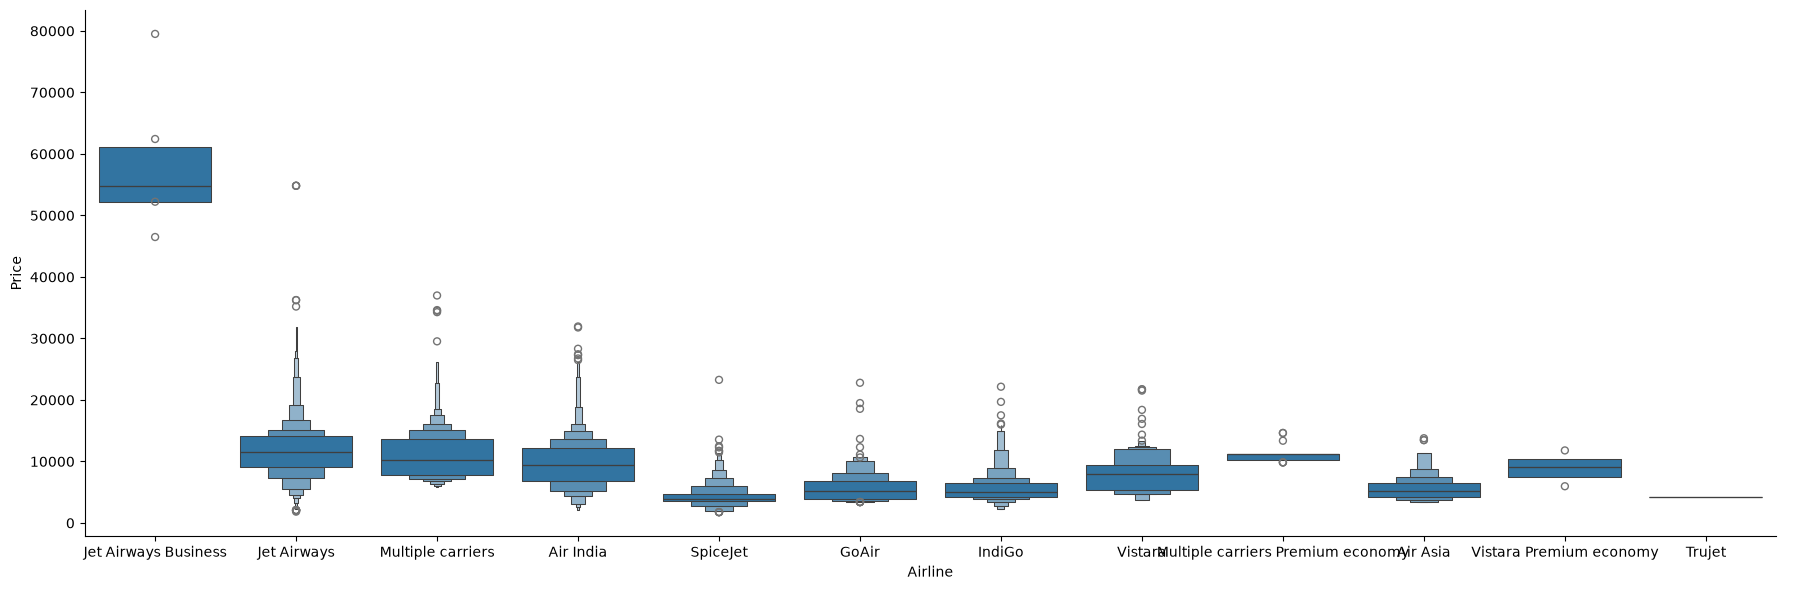

In [217]:
## From the graph we can see that jet Airways Business have the highest price.
## Apart from the first airline almost all are having similar medium

#Airline vs Price
sns.catplot(y='Price',x='Airline', data=train_df.sort_values('Price', ascending=False, ), kind='boxen', height=6, aspect=3)
plt.show()

In [218]:
Airline=train_df[['Airline']]
Airline=pd.get_dummies(Airline, drop_first=True).astype(int)
Airline.head(3)


,Airline_Air India,Airline_GoAir,Airline_IndiGo,Airline_Jet Airways,Airline_Jet Airways Business,Airline_Multiple carriers,Airline_Multiple carriers Premium economy,Airline_SpiceJet,Airline_Trujet,Airline_Vistara,Airline_Vistara Premium economy
0,0,0,1,0,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,0
2,0,0,0,1,0,0,0,0,0,0,0


In [219]:
train_df['Source'].value_counts()

Source
Delhi       4536
Kolkata     2871
Banglore    2197
Mumbai       697
Chennai      381
Name: count, dtype: int64

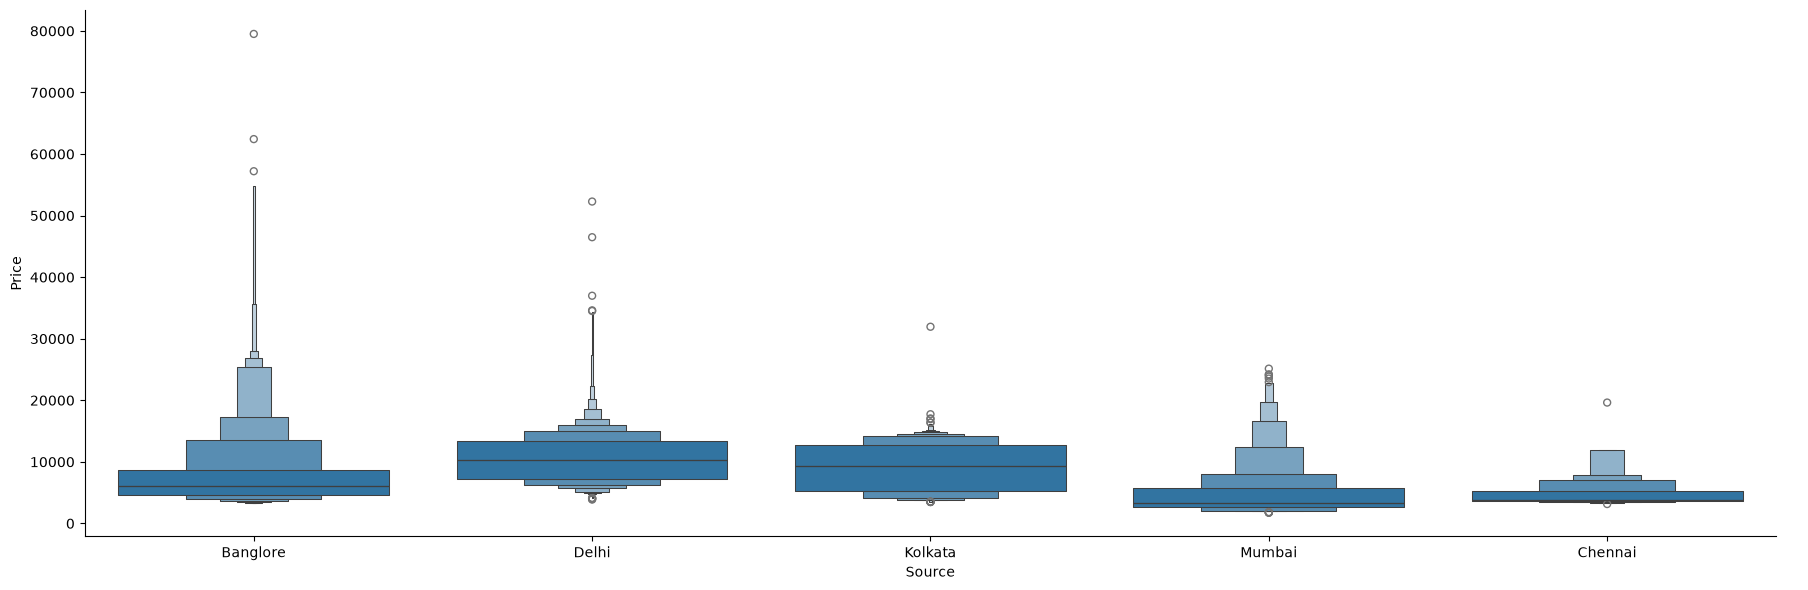

In [220]:
# Source vs Price
sns.catplot(x='Source', y='Price', data=train_df.sort_values('Price', ascending=False), kind='boxen', height=6, aspect=3)
plt.show()

In [221]:
# As Source is Nominal Categorical data we will perform OneHotEncoder
Source=train_df[['Source']]
Source=pd.get_dummies(Source, drop_first=True).astype(int)

In [222]:
Source.head()


,Source_Chennai,Source_Delhi,Source_Kolkata,Source_Mumbai
0,0,0,0,0
1,0,0,1,0
2,0,1,0,0
3,0,0,1,0
4,0,0,0,0


In [223]:
train_df['Destination'].value_counts()

Destination
Cochin       4536
Banglore     2871
Delhi        1265
New Delhi     932
Hyderabad     697
Kolkata       381
Name: count, dtype: int64

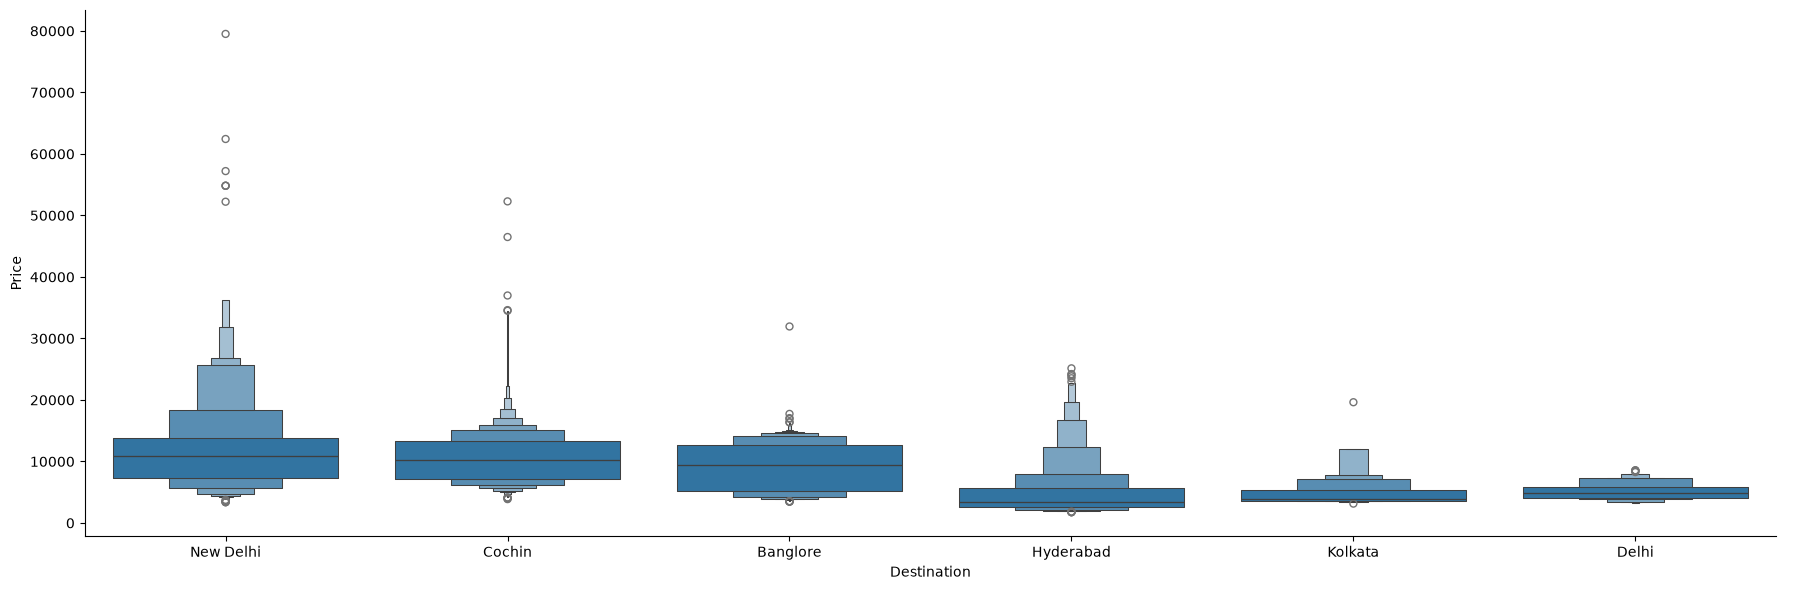

In [224]:
# Destination vs Price
sns.catplot(x='Destination', y='Price', data=train_df.sort_values('Price', ascending=False), kind='boxen', height=6, aspect=3)
plt.show()

In [225]:
Destination=train_df[['Destination']]
Destination=pd.get_dummies(Destination, drop_first=True).astype(int)
Destination.head()

,Destination_Cochin,Destination_Delhi,Destination_Hyderabad,Destination_Kolkata,Destination_New Delhi
0,0,0,0,0,1
1,0,0,0,0,0
2,1,0,0,0,0
3,0,0,0,0,0
4,0,0,0,0,1


In [226]:
train_df['Route']

0                    BLR ? DEL
1        CCU ? IXR ? BBI ? BLR
2        DEL ? LKO ? BOM ? COK
3              CCU ? NAG ? BLR
4              BLR ? NAG ? DEL
                 ...          
10678                CCU ? BLR
10679                CCU ? BLR
10680                BLR ? DEL
10681                BLR ? DEL
10682    DEL ? GOI ? BOM ? COK
Name: Route, Length: 10682, dtype: object

In [227]:
# additional_info contains almost 80% no_info
# Route and Total_Stops are related to each other

train_df.drop(['Route','Additional_Info'], axis=1, inplace=True)

In [228]:
train_df['Total_Stops'].value_counts()

Total_Stops
1 stop      5625
non-stop    3491
2 stops     1520
3 stops       45
4 stops        1
Name: count, dtype: int64

In [229]:
# As the Total_Stops is ordinal columns to we will perform LabelEncoder
# let assign values according thier keys
train_df['Total_Stops'].replace({'non-stop': 0, '1 stop':1, '2 stops':2, '3 stops':3, '4 stops':4}, inplace=True)
train_df.head()

C:\Users\A\AppData\Local\Temp\ipykernel_4588\2171736478.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df['Total_Stops'].replace({'non-stop': 0, '1 stop':1, '2 stops':2, '3 stops':3, '4 stops':4}, inplace=True)
C:\Users\A\AppData\Local\Temp\ipykernel_4588\2171736478.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_

,Airline,Source,Destination,Total_Stops,Price,journey_day,journey_month,dep_hour,dep_min,arrival_hour,arrival_min,duration_hour,duration_mins
0,IndiGo,Banglore,New Delhi,0,3897,24,3,22,20,1,10,2,50
1,Air India,Kolkata,Banglore,2,7662,1,5,5,50,13,15,7,25
2,Jet Airways,Delhi,Cochin,2,13882,9,6,9,25,4,25,19,0
3,IndiGo,Kolkata,Banglore,1,6218,12,5,18,5,23,30,5,25
4,IndiGo,Banglore,New Delhi,1,13302,1,3,16,50,21,35,4,45


In [230]:
# Now lets concatinate the dataframes
train_df=pd.concat([train_df, Airline, Source, Destination], axis=1)

In [231]:
train_df.head()

,Airline,Source,Destination,Total_Stops,Price,journey_day,journey_month,dep_hour,dep_min,arrival_hour,...,Airline_Vistara Premium economy,Source_Chennai,Source_Delhi,Source_Kolkata,Source_Mumbai,Destination_Cochin,Destination_Delhi,Destination_Hyderabad,Destination_Kolkata,Destination_New Delhi
0,IndiGo,Banglore,New Delhi,0,3897,24,3,22,20,1,...,0,0,0,0,0,0,0,0,0,1
1,Air India,Kolkata,Banglore,2,7662,1,5,5,50,13,...,0,0,0,1,0,0,0,0,0,0
2,Jet Airways,Delhi,Cochin,2,13882,9,6,9,25,4,...,0,0,1,0,0,1,0,0,0,0
3,IndiGo,Kolkata,Banglore,1,6218,12,5,18,5,23,...,0,0,0,1,0,0,0,0,0,0
4,IndiGo,Banglore,New Delhi,1,13302,1,3,16,50,21,...,0,0,0,0,0,0,0,0,0,1


In [232]:
# we need to drop these columns Airline	Source	Destination.
train_df.drop(columns=['Airline','Source','Destination'], axis=1, inplace=True)
train_df.head()

,Total_Stops,Price,journey_day,journey_month,dep_hour,dep_min,arrival_hour,arrival_min,duration_hour,duration_mins,...,Airline_Vistara Premium economy,Source_Chennai,Source_Delhi,Source_Kolkata,Source_Mumbai,Destination_Cochin,Destination_Delhi,Destination_Hyderabad,Destination_Kolkata,Destination_New Delhi
0,0,3897,24,3,22,20,1,10,2,50,...,0,0,0,0,0,0,0,0,0,1
1,2,7662,1,5,5,50,13,15,7,25,...,0,0,0,1,0,0,0,0,0,0
2,2,13882,9,6,9,25,4,25,19,0,...,0,0,1,0,0,1,0,0,0,0
3,1,6218,12,5,18,5,23,30,5,25,...,0,0,0,1,0,0,0,0,0,0
4,1,13302,1,3,16,50,21,35,4,45,...,0,0,0,0,0,0,0,0,0,1


In [233]:
train_df.shape

(10682, 30)

### Test set

In [234]:
test_df=pd.read_csv('Test_set.csv')
test_df.head(3)

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info
0,Jet Airways,6/06/2019,Delhi,Cochin,DEL ? BOM ? COK,17:30,04:25 07 Jun,10h 55m,1 stop,No info
1,IndiGo,12/05/2019,Kolkata,Banglore,CCU ? MAA ? BLR,06:20,10:20,4h,1 stop,No info
2,Jet Airways,21/05/2019,Delhi,Cochin,DEL ? BOM ? COK,19:15,19:00 22 May,23h 45m,1 stop,In-flight meal not included


In [235]:
test_df.shape

(2671, 10)

In [236]:
print('Test Data info')
print('-'*50)
print(test_df.info)

print()
print()

print('Null values : ')
print('-'*50)
test_df.dropna(inplace=True)
print(test_df.isnull().sum())

#Test set EDA

# Date_of_journey
test_df['journey_day']=pd.to_datetime(test_df['Date_of_Journey'], format='%d/%m/%Y').dt.day
test_df['journey_month']=pd.to_datetime(test_df['Date_of_Journey'], format='%d/%m/%Y').dt.month
test_df.drop('Date_of_Journey', axis=1, inplace=True)

#Dep_time
test_df['dep_hour']=pd.to_datetime(test_df['Dep_Time']).dt.hour
test_df['dep_min']=pd.to_datetime(test_df['Dep_Time']).dt.minute
test_df.drop('Dep_Time', axis=1, inplace=True)

# Arrival_time
test_df['arrival_hour']=pd.to_datetime(test_df['Arrival_Time']).dt.hour
test_df['arrival_min']=pd.to_datetime(test_df['Arrival_Time']).dt.minute
test_df.drop('Arrival_Time', axis=1, inplace=True)

# Time taken by a plan to reach from source to destination is called Duration
# lets extract the information from Duration column and convert new feature like hour and min
duration = list(test_df['Duration'])

for i in range(len(duration)):
    if len(duration[i].split()) != 2:
        if 'h' in duration[i]:
            duration[i] = duration[i].strip() + ' 0m'   # only hours, e.g. "19h" -> "19h 0m"
        else:
            duration[i] = '0h ' + duration[i].strip()   # only minutes, e.g. "5m" -> "0h 5m"
    # else: already has both "Xh Ym", leave it alone

duration_hour = []
duration_min = []

for i in range(len(duration)):
    duration_hour.append(int(duration[i].split(sep='h')[0]))
    duration_min.append(int(duration[i].split(sep='m')[0].split()[-1]))

test_df['duration_hour']=duration_hour
test_df['duration_mins']=duration_min

# drop Duration column
test_df.drop('Duration', axis=1, inplace=True)

# Airline is Nominal data thats why we will use OneHotEncoder
Airline=test_df[['Airline']]
Airline=pd.get_dummies(Airline, drop_first=True).astype(int)

# Encode Source column
Source=test_df[['Source']]
Source=pd.get_dummies(Source, drop_first=True).astype(int)

# Encode Destination column
Destination=test_df[['Destination']]
Destination=pd.get_dummies(Destination, drop_first=True).astype(int)

# Route and Total_Stops are related to each other
test_df.drop(['Route','Additional_Info'], axis=1, inplace=True)

# Convert stop to a numrical value. Labelwise
test_df['Total_Stops'].replace({'non-stop': 0, '1 stop':1, '2 stops':2, '3 stops':3, '4 stops':4}, inplace=True)
test_df.head()

# Now lets concatinate the dataframes
test_df=pd.concat([test_df, Airline, Source, Destination], axis=1)

#Drop below columns
test_df.drop(columns=['Airline','Source','Destination'], axis=1, inplace=True)
test_df.head()

print()
print()
print(test_df.shape)




Test Data info
--------------------------------------------------
<bound method DataFrame.info of                 Airline Date_of_Journey    Source Destination  \
0           Jet Airways       6/06/2019     Delhi      Cochin   
1                IndiGo      12/05/2019   Kolkata    Banglore   
2           Jet Airways      21/05/2019     Delhi      Cochin   
3     Multiple carriers      21/05/2019     Delhi      Cochin   
4              Air Asia      24/06/2019  Banglore       Delhi   
...                 ...             ...       ...         ...   
2666          Air India       6/06/2019   Kolkata    Banglore   
2667             IndiGo      27/03/2019   Kolkata    Banglore   
2668        Jet Airways       6/03/2019     Delhi      Cochin   
2669          Air India       6/03/2019     Delhi      Cochin   
2670  Multiple carriers      15/06/2019     Delhi      Cochin   

                Route Dep_Time  Arrival_Time Duration Total_Stops  \
0     DEL ? BOM ? COK    17:30  04:25 07 Jun  10h 55

C:\Users\A\AppData\Local\Temp\ipykernel_4588\4083987035.py:21: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  test_df['dep_hour']=pd.to_datetime(test_df['Dep_Time']).dt.hour
C:\Users\A\AppData\Local\Temp\ipykernel_4588\4083987035.py:22: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  test_df['dep_min']=pd.to_datetime(test_df['Dep_Time']).dt.minute
C:\Users\A\AppData\Local\Temp\ipykernel_4588\4083987035.py:26: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  test_df['arrival_hour']=pd.to_datetime(test_df['Arrival_Time']).dt.hour
C:\Users\A\AppData\Local\Temp\ipykernel_4588\4083987



(2671, 28)


C:\Users\A\AppData\Local\Temp\ipykernel_4588\4083987035.py:71: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test_df['Total_Stops'].replace({'non-stop': 0, '1 stop':1, '2 stops':2, '3 stops':3, '4 stops':4}, inplace=True)
C:\Users\A\AppData\Local\Temp\ipykernel_4588\4083987035.py:71: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no

In [237]:
test_df.head()

,Total_Stops,journey_day,journey_month,dep_hour,dep_min,arrival_hour,arrival_min,duration_hour,duration_mins,Airline_Air India,...,Airline_Vistara Premium economy,Source_Chennai,Source_Delhi,Source_Kolkata,Source_Mumbai,Destination_Cochin,Destination_Delhi,Destination_Hyderabad,Destination_Kolkata,Destination_New Delhi
0,1,6,6,17,30,4,25,10,55,0,...,0,0,1,0,0,1,0,0,0,0
1,1,12,5,6,20,10,20,4,0,0,...,0,0,0,1,0,0,0,0,0,0
2,1,21,5,19,15,19,0,23,45,0,...,0,0,1,0,0,1,0,0,0,0
3,1,21,5,8,0,21,0,13,0,0,...,0,0,1,0,0,1,0,0,0,0
4,0,24,6,23,55,2,45,2,50,0,...,0,0,0,0,0,0,1,0,0,0


In [265]:
train_df.to_csv('train_processed.csv', index=False)
test_df.to_csv('test_processed.csv', index=False)

### Feature Selection
Find the out the best features which will contribute and have a good relation with target variable.
Following are some of the feature selection methods.
1. heatmap
2. feature_importance_
3. SelectKBest

In [238]:
train_df.shape

(10682, 30)

In [239]:
train_df.columns

Index(['Total_Stops', 'Price', 'journey_day', 'journey_month', 'dep_hour',
       'dep_min', 'arrival_hour', 'arrival_min', 'duration_hour',
       'duration_mins', 'Airline_Air India', 'Airline_GoAir', 'Airline_IndiGo',
       'Airline_Jet Airways', 'Airline_Jet Airways Business',
       'Airline_Multiple carriers',
       'Airline_Multiple carriers Premium economy', 'Airline_SpiceJet',
       'Airline_Trujet', 'Airline_Vistara', 'Airline_Vistara Premium economy',
       'Source_Chennai', 'Source_Delhi', 'Source_Kolkata', 'Source_Mumbai',
       'Destination_Cochin', 'Destination_Delhi', 'Destination_Hyderabad',
       'Destination_Kolkata', 'Destination_New Delhi'],
      dtype='object')

In [240]:
X=train_df.loc[:,['Total_Stops','journey_day', 'journey_month', 'dep_hour',
       'dep_min', 'arrival_hour', 'arrival_min', 'duration_hour',
       'duration_mins', 'Airline_Air India', 'Airline_GoAir', 'Airline_IndiGo',
       'Airline_Jet Airways', 'Airline_Jet Airways Business',
       'Airline_Multiple carriers',
       'Airline_Multiple carriers Premium economy', 'Airline_SpiceJet',
       'Airline_Trujet', 'Airline_Vistara', 'Airline_Vistara Premium economy',
       'Source_Chennai', 'Source_Delhi', 'Source_Kolkata', 'Source_Mumbai',
       'Destination_Cochin', 'Destination_Delhi', 'Destination_Hyderabad',
       'Destination_Kolkata', 'Destination_New Delhi']]
X.head()

,Total_Stops,journey_day,journey_month,dep_hour,dep_min,arrival_hour,arrival_min,duration_hour,duration_mins,Airline_Air India,...,Airline_Vistara Premium economy,Source_Chennai,Source_Delhi,Source_Kolkata,Source_Mumbai,Destination_Cochin,Destination_Delhi,Destination_Hyderabad,Destination_Kolkata,Destination_New Delhi
0,0,24,3,22,20,1,10,2,50,0,...,0,0,0,0,0,0,0,0,0,1
1,2,1,5,5,50,13,15,7,25,1,...,0,0,0,1,0,0,0,0,0,0
2,2,9,6,9,25,4,25,19,0,0,...,0,0,1,0,0,1,0,0,0,0
3,1,12,5,18,5,23,30,5,25,0,...,0,0,0,1,0,0,0,0,0,0
4,1,1,3,16,50,21,35,4,45,0,...,0,0,0,0,0,0,0,0,0,1


In [241]:
y=train_df['Price']

In [242]:
y.head()

0     3897
1     7662
2    13882
3     6218
4    13302
Name: Price, dtype: int64

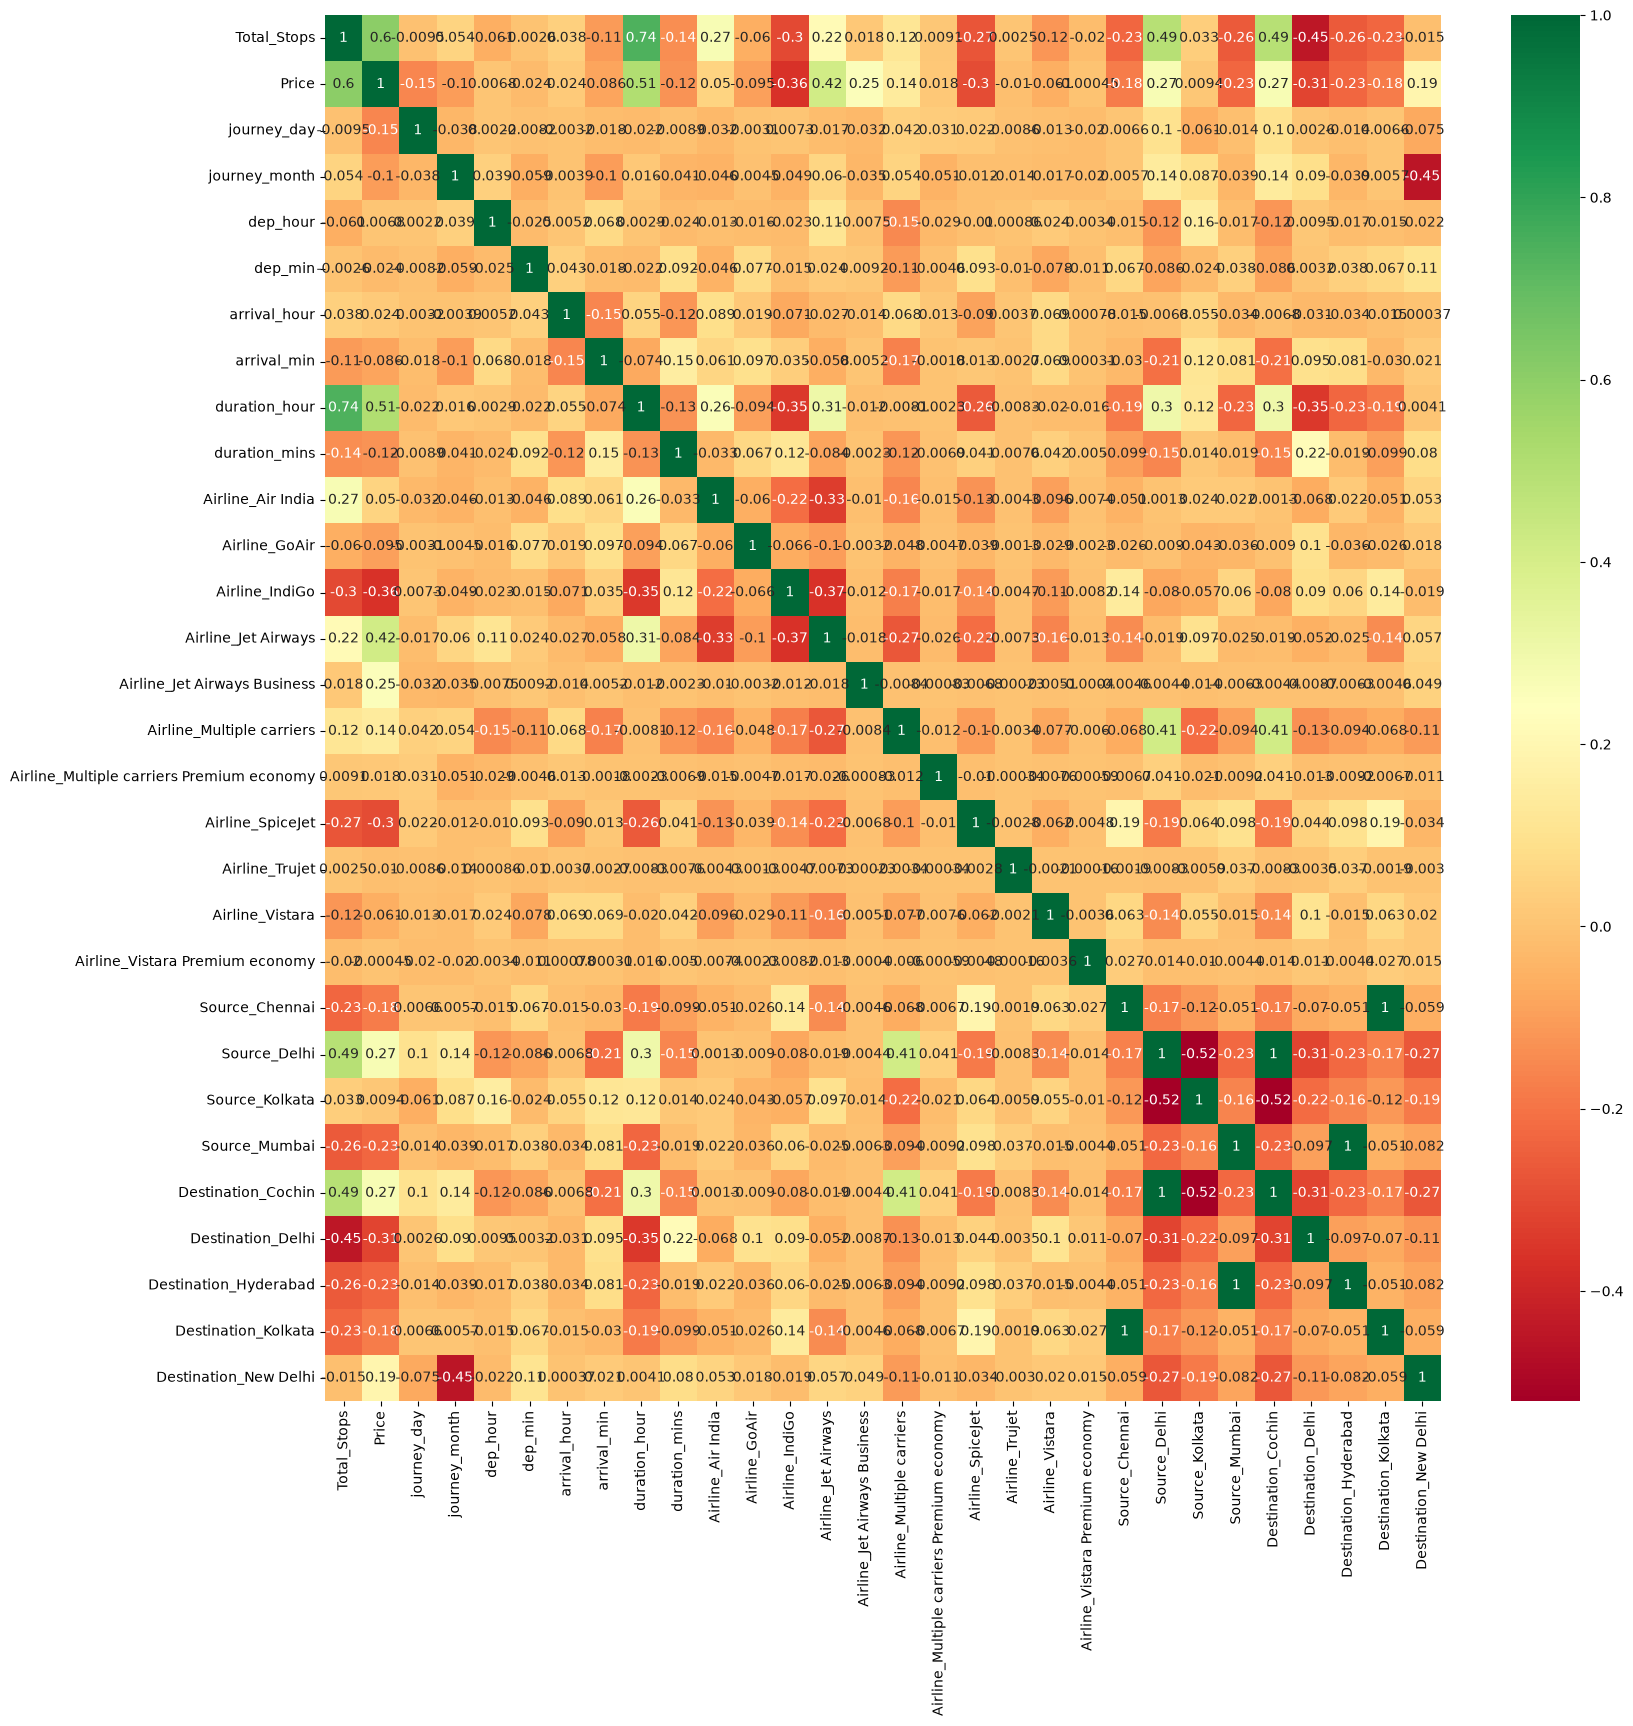

In [243]:
# Find Correlation between independent and dependent attributes

plt.figure(figsize=(18,18))
sns.heatmap(train_df.corr(), annot=True, cmap='RdYlGn')
plt.show()


In [244]:
# Finding important feature using ExtraTreeRegressor

from sklearn.ensemble import ExtraTreesRegressor
selection=ExtraTreesRegressor()
selection.fit(X,y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, 

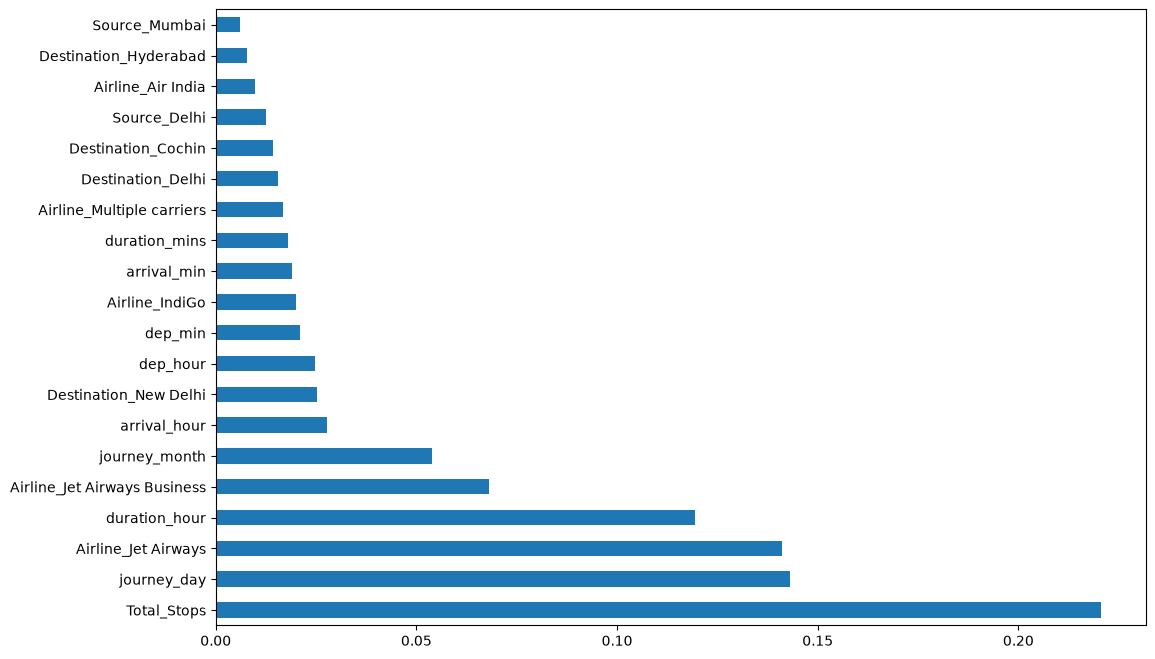

In [245]:
# lets plot the graph of feature importance for better visulization
plt.figure(figsize=(12,8))
feat_importances=pd.Series(selection.feature_importances_, index=X.columns)
feat_importances.nlargest(20).plot(kind='barh')
plt.show()